## 1. Importar librerías y cargar los datasets

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

base = "https://raw.githubusercontent.com/Semillero-Inteligencia-Artificial-EAFIT/p-REDbloodDON/main/data/"

banco = pd.read_csv(
    base + "Banco_de_sangre,_Hospital_General_de_Medell%C3%ADn_20260508.csv",
    encoding="latin-1",
)
defunciones = pd.read_csv(
    base
    + "Defunciones_ocurridas_en__en_el_Hospital_General_de_Medell%C3%ADn_20260508.csv",
    encoding="latin-1",
)
poblacion1 = pd.read_csv(
    base
    + "Poblaci%C3%B3n_atendida_en_el_Hospital_General_de_Medell%C3%ADn_20260508.csv",
    encoding="latin-1",
)
poblacion2 = pd.read_csv(
    base + "poblacion_atendida_hospital_general.csv", encoding="latin-1"
)

print("Banco: ", banco.shape)
print("Defunciones:", defunciones.shape)
print("Población 1:", poblacion1.shape)
print("Población 2:", poblacion2.shape)

Banco:  (35840, 11)
Defunciones: (5094, 26)
Población 1: (221203, 12)
Población 2: (182700, 12)


C:\Users\jomig\AppData\Local\Temp\ipykernel_22340\2940628631.py:22: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  poblacion2 = pd.read_csv(


## 2. Diagnostico de los datos

In [51]:
for nombre, df in [
    ("Banco", banco),
    ("Defunciones", defunciones),
    ("Población 1", poblacion1),
    ("Población 2", poblacion2),
]:
    print(f"{'─'*40}")
    print(f"  {nombre}")
    print(f"{'─'*40}")
    print(df.columns.tolist())
    print(df.head(2))

────────────────────────────────────────
  Banco
────────────────────────────────────────
['ANO', 'TRIMESTRE', 'FECHA EXTRACCION', 'RH', 'BARRIO', 'CIUDAD', 'EDAD', 'ESTATURA', 'FECHA NACIMIENTO', 'PESO', 'SEXO']
    ANO  TRIMESTRE FECHA EXTRACCION  RH       BARRIO    CIUDAD  EDAD  \
0  2020          4       28/12/2020  0+    POPULAR 1  MEDELLIN  41.0   
1  2020          1       01/02/2020  0+  20 DE JULIO  MEDELLIN  43.0   

   ESTATURA         FECHA NACIMIENTO  PESO SEXO  
0       NaN  1982 Jan 01 12:00:00 AM   NaN    M  
1      1.74  1979 Mar 12 12:00:00 AM  80.0    M  
────────────────────────────────────────
  Defunciones
────────────────────────────────────────
['AÃ\x91O', 'Trimestre', 'SITIO DEFUNCION', 'TIPO DEFUNCION', 'FECHA DEFUNCION', 'SEXO FALLECIDO', 'ESTADO CONYUGAL FALLECIDO', 'EDAD FALLECIDO', 'NIVEL EDUCATIVO FALLECIDO', 'ULTIMO ANO APROBADO FALLECIDO', 'OCUPACION FALLECIDO', 'PERTENENCIA ETNICA', 'GRUPO INDIGENA', 'PAIS RESIDENCIA', 'DEPARTAMENTO RESIDENCIA', 'MUNICI

In [52]:
for nombre, df in [
    ("Banco", banco),
    ("Defunciones", defunciones),
    ("Población 1", poblacion1),
    ("Población 2", poblacion2),
]:
    print(f"\n{'─'*60}")
    print(f"INFO: {nombre}")
    print(f"{'─'*60}")
    df.info()


────────────────────────────────────────────────────────────
INFO: Banco
────────────────────────────────────────────────────────────
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35840 entries, 0 to 35839
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ANO               35840 non-null  int64  
 1   TRIMESTRE         35840 non-null  int64  
 2   FECHA EXTRACCION  35840 non-null  object 
 3   RH                35799 non-null  object 
 4   BARRIO            28052 non-null  object 
 5   CIUDAD            35840 non-null  object 
 6   EDAD              35838 non-null  float64
 7   ESTATURA          35761 non-null  float64
 8   FECHA NACIMIENTO  35838 non-null  object 
 9   PESO              35799 non-null  float64
 10  SEXO              35839 non-null  object 
dtypes: float64(3), int64(2), object(6)
memory usage: 3.0+ MB

────────────────────────────────────────────────────────────
INFO: Defunciones
───

## 3. Limpieza

In [53]:
def limpiar(df):
    df = df.copy()
    # Corregir encoding en nombres de columnas
    df.columns = (
        df.columns.str.strip()
        .str.encode("latin-1", errors="ignore")
        .str.decode("utf-8", errors="ignore")
        .str.lower()
        .str.replace(" ", "_")
    )
    df = df.rename(columns={"ano": "año", "ao": "año"})
    # Duplicados
    df = df.drop_duplicates()
    # Nulos numericos -> mediana
    nums = df.select_dtypes(include="number").columns
    df.loc[:, nums] = df[nums].fillna(df[nums].median())
    # Nulos categoricos -> moda
    for col in df.select_dtypes(include="object").columns:
        df.loc[:, col] = df[col].fillna(df[col].mode()[0])
    return df


banco = limpiar(banco)
defunciones = limpiar(defunciones)
poblacion1 = limpiar(poblacion1)
poblacion2 = limpiar(poblacion2)

# Verificar que ANO quedo bien
print(banco.columns.tolist())
print(defunciones.columns.tolist())
print(poblacion1.columns.tolist())
print(poblacion2.columns.tolist())

['año', 'trimestre', 'fecha_extraccion', 'rh', 'barrio', 'ciudad', 'edad', 'estatura', 'fecha_nacimiento', 'peso', 'sexo']
['año', 'trimestre', 'sitio_defuncion', 'tipo_defuncion', 'fecha_defuncion', 'sexo_fallecido', 'estado_conyugal_fallecido', 'edad_fallecido', 'nivel_educativo_fallecido', 'ultimo_ano_aprobado_fallecido', 'ocupacion_fallecido', 'pertenencia_etnica', 'grupo_indigena', 'pais_residencia', 'departamento_residencia', 'municipio_residencia', 'area_residencia', 'localidad', 'regimen_seguridad', 'nombre_administradora', 'probable_manera_muerte', 'causa_directa', 'causa_antecedentes_b', 'causa_antecedentes_c', 'causa_antecedentes_d', 'estados_patologicos']
['año', 'periodo_de_reporte', 'fecha_atencion', 'servicio', 'sexo', 'cod._aseguradora', 'aseguradora', 'poblacion', 'departamento', 'edad', 'rango_de_edad', 'regimen']
['año', 'periodo_reporte', 'fecha_atencion', 'servicio', 'sexo', 'codigo_aseguradora', 'aseguradora', 'poblacion', 'departamento', 'edad', 'rango_edad', 're

In [54]:
# Estandarizar nombres de columnas para poder unir las tablas de población
poblacion2 = poblacion2.rename(
    columns={
        "año": "año",
        "periodo_reporte": "periodo_de_reporte",
        "fecha_atencion": "fecha_atencion",
        "rango_edad": "rango_de_edad",
        "codigo_aseguradora": "cod._aseguradora",
    }
)

# Parsear cada dataset con su formato propio
poblacion1["fecha_atencion"] = pd.to_datetime(
    poblacion1["fecha_atencion"], format="%d/%m/%Y", errors="coerce"
)

poblacion2["fecha_atencion"] = pd.to_datetime(
    poblacion2["fecha_atencion"], format="%Y-%m-%dT%H:%M:%S.%f%z", errors="coerce"
).dt.tz_localize(
    None
)  # eliminar la zona horaria para que sean compatibles

poblacion = pd.concat([poblacion1, poblacion2], ignore_index=True)
poblacion = poblacion.drop_duplicates()
print("Población unificada:", poblacion.shape)

Población unificada: (386649, 12)


In [55]:
banco["fecha_extraccion"] = pd.to_datetime(
    banco["fecha_extraccion"], dayfirst=True, errors="coerce"
)
defunciones["fecha_defuncion"] = pd.to_datetime(
    defunciones["fecha_defuncion"], dayfirst=True, errors="coerce"
)
poblacion["fecha_atencion"] = pd.to_datetime(
    poblacion["fecha_atencion"], dayfirst=True, errors="coerce"
)

print("Banco nulos fecha: ", banco["fecha_extraccion"].isna().sum())
print("Defunciones nulos fecha: ", defunciones["fecha_defuncion"].isna().sum())
print("Población nulos fecha: ", poblacion["fecha_atencion"].isna().sum())

Banco nulos fecha:  0
Defunciones nulos fecha:  0
Población nulos fecha:  0


## 4. Serie de timpo mensual

In [56]:
# Donaciones por mes
serie_banco = (
    banco.groupby(pd.Grouper(key="fecha_extraccion", freq="ME"))
    .size()
    .reset_index(name="donaciones")
)

# Defunciones por mes
serie_def = (
    defunciones.groupby(pd.Grouper(key="fecha_defuncion", freq="ME"))
    .size()
    .reset_index(name="defunciones")
)

# Atenciones por mes
serie_pob = (
    poblacion.groupby(pd.Grouper(key="fecha_atencion", freq="ME"))
    .size()
    .reset_index(name="atenciones")
)

# Unir todo en una sola serie
serie_def = serie_def.rename(columns={"fecha_defuncion": "fecha"})
serie_pob = serie_pob.rename(columns={"fecha_atencion": "fecha"})
serie_banco = serie_banco.rename(columns={"fecha_extraccion": "fecha"})

serie = serie_banco.merge(serie_def, on="fecha", how="left").merge(
    serie_pob, on="fecha", how="left"
)

print(serie.tail(10))

        fecha  donaciones  defunciones  atenciones
56 2024-09-30         711         95.0      3123.0
57 2024-10-31         519         97.0      3850.0
58 2024-11-30         497         95.0      3364.0
59 2024-12-31         317        113.0      3975.0
60 2025-01-31         430        113.0      3191.0
61 2025-02-28         613         90.0      1758.0
62 2025-03-31         522         98.0      2098.0
63 2025-04-30         484        107.0      2657.0
64 2025-05-31         656        118.0      2356.0
65 2025-06-30         433        101.0      2505.0


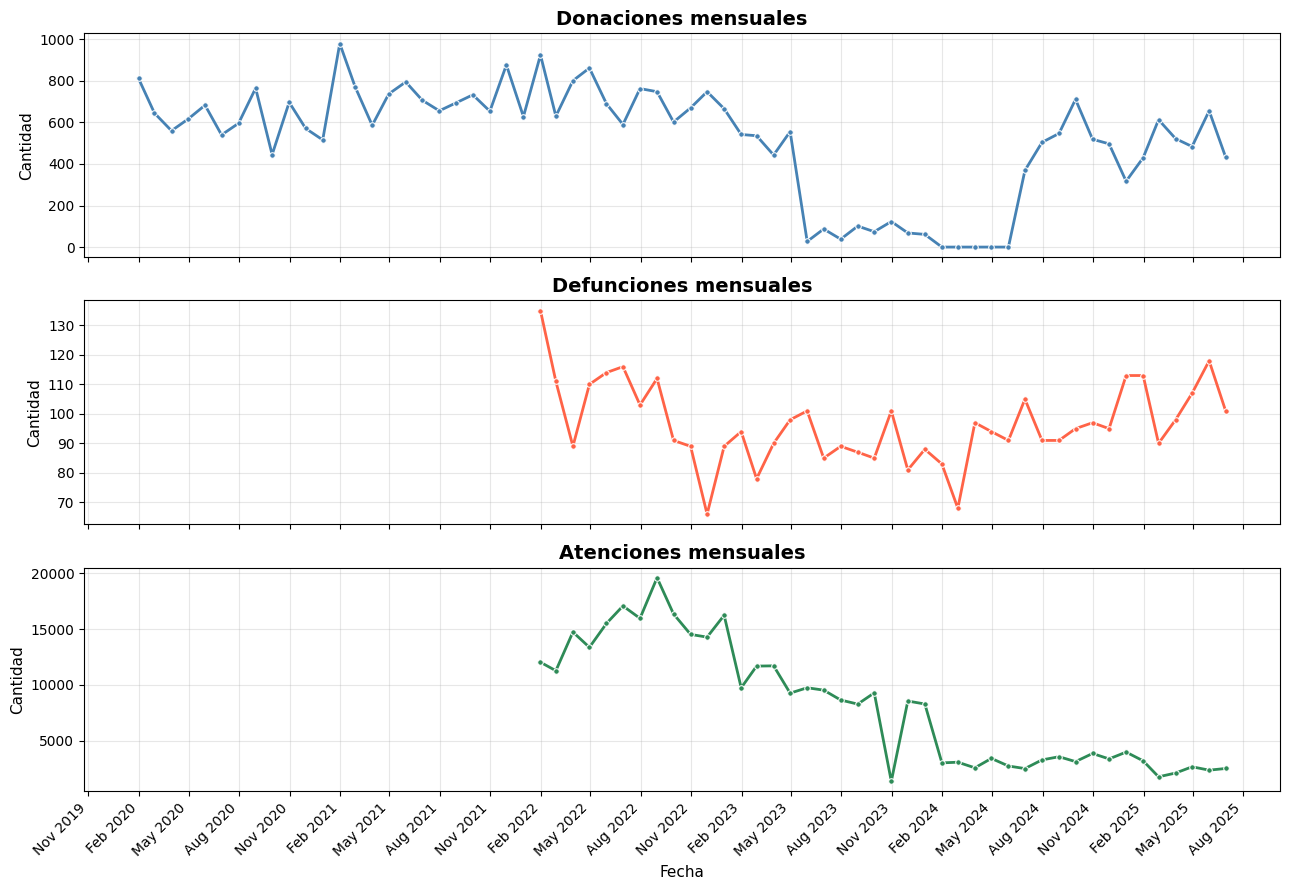

In [57]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

sns.lineplot(
    data=serie,
    x="fecha",
    y="donaciones",
    ax=axes[0],
    color="steelblue",
    linewidth=2,
    marker="o",
    markersize=4,
)
axes[0].set_title("Donaciones mensuales", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Cantidad", fontsize=11)
axes[0].grid(True, alpha=0.3)

sns.lineplot(
    data=serie,
    x="fecha",
    y="defunciones",
    ax=axes[1],
    color="tomato",
    linewidth=2,
    marker="o",
    markersize=4,
)
axes[1].set_title("Defunciones mensuales", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Cantidad", fontsize=11)
axes[1].grid(True, alpha=0.3)

sns.lineplot(
    data=serie,
    x="fecha",
    y="atenciones",
    ax=axes[2],
    color="seagreen",
    linewidth=2,
    marker="o",
    markersize=4,
)
axes[2].set_title("Atenciones mensuales", fontsize=14, fontweight="bold")
axes[2].set_ylabel("Cantidad", fontsize=11)
axes[2].set_xlabel("Fecha", fontsize=11)
axes[2].grid(True, alpha=0.3)

# Formato de fechas en eje X
axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(axes[2].get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [58]:
# Identificar meses con donaciones anormalmente bajas
umbral = serie["donaciones"].quantile(0.10)  # percentil 10
print(f"Umbral mínimo razonable: {umbral:.0f} donaciones/mes")

serie["dato_incompleto"] = (serie["donaciones"] < umbral).astype(int)
print(serie[serie["dato_incompleto"] == 1][["fecha", "donaciones"]])

Umbral mínimo razonable: 50 donaciones/mes
        fecha  donaciones
40 2023-05-31          27
42 2023-07-31          38
48 2024-01-31           0
49 2024-02-29           0
50 2024-03-31           0
51 2024-04-30           0
52 2024-05-31           0


In [59]:
# Ver el rango de fechas de cada dataset
print("Banco: ", banco["fecha_extraccion"].min(), "→", banco["fecha_extraccion"].max())
print(
    "Defunciones:",
    defunciones["fecha_defuncion"].min(),
    "→",
    defunciones["fecha_defuncion"].max(),
)
print(
    "Población: ",
    poblacion["fecha_atencion"].min(),
    "→",
    poblacion["fecha_atencion"].max(),
)

Banco:  2020-01-02 00:00:00 → 2025-06-27 00:00:00
Defunciones: 2022-01-01 00:00:00 → 2026-03-31 00:00:00
Población:  2022-01-02 00:00:00 → 2026-03-31 00:00:00


In [60]:
# Solo excluir si es literalmente 0 (ausencia de reporte en las donaciones)
# Y solo el período confirmado sin registros
serie["dato_valido"] = ~(
    (serie["donaciones"] == 0)
    & (serie["fecha"] >= "2024-01-01")
    & (serie["fecha"] <= "2024-05-31")
)

serie_modelo = serie[serie["dato_valido"]].copy()

print(f"Meses válidos: {len(serie_modelo)}")
print(serie_modelo[["fecha", "donaciones"]].sort_values("donaciones").head(10))

Meses válidos: 61
        fecha  donaciones
40 2023-05-31          27
42 2023-07-31          38
47 2023-12-31          61
46 2023-11-30          68
44 2023-09-30          74
41 2023-06-30          87
43 2023-08-31         101
45 2023-10-31         123
59 2024-12-31         317
53 2024-06-30         369


In [61]:
# Reemplazar 0 por NaN solo en el período sin reporte
serie.loc[
    (serie["donaciones"] == 0)
    & (serie["fecha"] >= "2024-01-01")
    & (serie["fecha"] <= "2024-05-31"),
    "donaciones",
] = np.nan

# Interpolación lineal
serie["donaciones"] = (
    serie["donaciones"].interpolate(method="linear").round().astype(int)
)

# Verificar
print("Nulos restantes:", serie["donaciones"].isna().sum())
print(
    serie[["fecha", "donaciones"]].loc[
        (serie["fecha"] >= "2024-01-01") & (serie["fecha"] <= "2024-05-31")
    ]
)

Nulos restantes: 0
        fecha  donaciones
48 2024-01-31         112
49 2024-02-29         164
50 2024-03-31         215
51 2024-04-30         266
52 2024-05-31         318


## 5. guardar DataSet serie de tiempo

In [62]:
serie_modelo = serie[serie["fecha"] >= "2022-01-01"].copy()
serie_modelo.to_csv("data/serie_modelo.csv", index=False)
print("Serie final:", serie_modelo.shape)

Serie final: (42, 6)
